# QSAR Modeling of Kinase Inhibitor Libraries for ADMET Property Prediction

**Author:** Mahdi Aarabi, Ph.D., Computational Scientist

## Objective

This notebook develops quantitative structure–activity relationship (QSAR) models to predict
physicochemical and ADMET-relevant properties of kinase inhibitor libraries using molecular
fingerprints and machine learning. The workflow demonstrates an end-to-end cheminformatics
pipeline: molecular representation → descriptor generation → model training → evaluation.

**Target Properties:**
- pIC50 (binding potency)
- logP (lipophilicity)
- logS (aqueous solubility)

**Kinase Targets:** EGFR, JAK2, BCR-ABL, VEGFR, ALK, BRAF, MEK, CDK4/6

**Tools:** RDKit, scikit-learn, Pandas, NumPy, Matplotlib

## 1. Environment Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Draw
from rdkit.Chem import PandasTools
from rdkit import DataStructs

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

print('All packages loaded successfully.')

All packages loaded successfully.


## 2. Dataset Loading & Validation

The dataset contains 30 FDA-approved kinase inhibitors with experimentally measured
properties. SMILES representations are validated through RDKit parsing to ensure
chemical integrity before descriptor generation.

In [20]:
# Load dataset
df = pd.read_csv('kinase_inhibitors_dataset.csv')
print(f'Loaded {len(df)} compounds across {df["target"].nunique()} kinase targets')
print(f'\nTarget distribution:')
print(df['target'].value_counts())

# Validate SMILES and create RDKit molecule objects
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
invalid = df['mol'].isna().sum()
print(f'\nSMILES validation: {len(df) - invalid}/{len(df)} valid molecules')
df = df.dropna(subset=['mol']).reset_index(drop=True)

Loaded 30 compounds across 13 kinase targets

Target distribution:
target
EGFR           6
BCR-ABL        5
JAK2           5
CDK4/6         3
ALK            2
BRAF           2
EGFR/HER2      1
EGFR/VEGFR     1
VEGFR/PDGFR    1
VEGFR          1
VEGFR/RAF      1
VEGFR/MET      1
MEK            1
Name: count, dtype: int64

SMILES validation: 29/30 valid molecules


[05:31:00] SMILES Parse Error: unclosed ring for input: 'CC(Oc1cc(C)cnc1Nc1ccc2c(c1)[nH]c(=O)/c1cc(Cl)cc(Cl)c1C/1=N\2)c1c(Cl)ccc(OC)c1'


In [21]:
# Quick look at the data
df[['name', 'target', 'pIC50', 'logP', 'logS', 'MW', 'TPSA']].head(10)

,name,target,pIC50,logP,logS,MW,TPSA
0,Erlotinib,EGFR,7.82,3.20,-4.51,393.44,74.73
1,Gefitinib,EGFR,7.41,3.75,-4.89,446.90,68.74
2,Lapatinib,EGFR,8.15,4.64,-5.78,581.06,114.73
3,Afatinib,EGFR,8.92,3.76,-4.95,485.94,88.61
4,Osimertinib,EGFR,8.45,3.43,-4.67,499.62,87.58
5,Vandetanib,EGFR/VEGFR,7.10,2.95,-4.32,475.35,59.51
6,Neratinib,EGFR/HER2,8.68,4.41,-5.55,557.04,120.64
7,Dacomitinib,EGFR,8.30,3.58,-4.82,469.94,81.38
8,Ruxolitinib,JAK2,8.05,2.12,-3.54,306.37,83.18
9,Tofacitinib,JAK2,7.65,1.24,-2.78,312.37,88.73


## 3. Molecular Descriptor Generation

Two complementary molecular representations are generated:

1. **Extended-Connectivity Fingerprints (ECFP4):** 2048-bit circular fingerprints
   (Morgan radius=2) encoding substructural features. These capture local chemical
   environments around each atom.

2. **Physicochemical Descriptors:** RDKit-computed 2D descriptors including molecular
   weight, logP, TPSA, hydrogen bond donors/acceptors, rotatable bonds, and aromatic
   ring count, properties directly relevant to ADMET profiling.

In [22]:
# ---- ECFP4 Fingerprints (Morgan, radius=2, 2048 bits) ----
def mol_to_ecfp(mol, radius=2, n_bits=2048):
    """Generate ECFP fingerprint as numpy array."""
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros(n_bits, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

ecfp_matrix = np.array([mol_to_ecfp(mol) for mol in df['mol']])
print(f'ECFP4 fingerprint matrix: {ecfp_matrix.shape}')
print(f'Average bits ON per molecule: {ecfp_matrix.sum(axis=1).mean():.1f} / 2048')

ECFP4 fingerprint matrix: (29, 2048)
Average bits ON per molecule: 60.8 / 2048


[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerator
[05:31:00] DEPRECATION WARNING: please use MorganGenerat

In [23]:
# ---- Physicochemical Descriptors ----
def compute_descriptors(mol):
    """Compute a panel of RDKit 2D descriptors relevant to ADMET."""
    return {
        'MW': Descriptors.MolWt(mol),
        'LogP_calc': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol),
        'HeavyAtoms': Descriptors.HeavyAtomCount(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol),
        'NumRings': Descriptors.RingCount(mol),
        'MolRefractivity': Descriptors.MolMR(mol),
        'NumHeteroatoms': Descriptors.NumHeteroatoms(mol),
    }

desc_df = pd.DataFrame([compute_descriptors(mol) for mol in df['mol']])
print(f'Computed {len(desc_df.columns)} physicochemical descriptors for {len(desc_df)} molecules')
print(f'\nDescriptor summary statistics:')
desc_df.describe().round(2)

Computed 12 physicochemical descriptors for 29 molecules

Descriptor summary statistics:


,MW,LogP_calc,TPSA,HBA,HBD,RotBonds,AromaticRings,HeavyAtoms,FractionCSP3,NumRings,MolRefractivity,NumHeteroatoms
count,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00
mean,473.27,4.50,89.90,6.38,1.83,7.03,3.41,33.41,0.30,4.24,128.99,9.14
std,68.25,1.31,15.31,1.52,0.76,2.85,0.73,4.45,0.12,0.79,18.40,1.88
min,312.38,1.10,59.51,3.00,0.00,3.00,2.00,23.00,0.08,3.00,86.67,5.00
25%,446.91,3.89,79.38,5.00,1.00,5.00,3.00,31.00,0.19,4.00,118.15,8.00
50%,469.95,4.76,88.61,7.00,2.00,7.00,3.00,33.00,0.30,4.00,128.84,9.00
75%,518.61,5.36,103.88,7.00,2.00,9.00,4.00,36.00,0.36,5.00,138.99,10.00
max,609.78,6.40,120.56,9.00,3.00,14.00,5.00,45.00,0.50,6.00,181.36,13.00


## 4. Exploratory Data Analysis

Examining the distribution of target properties and correlations between
molecular descriptors to identify potential predictive features.

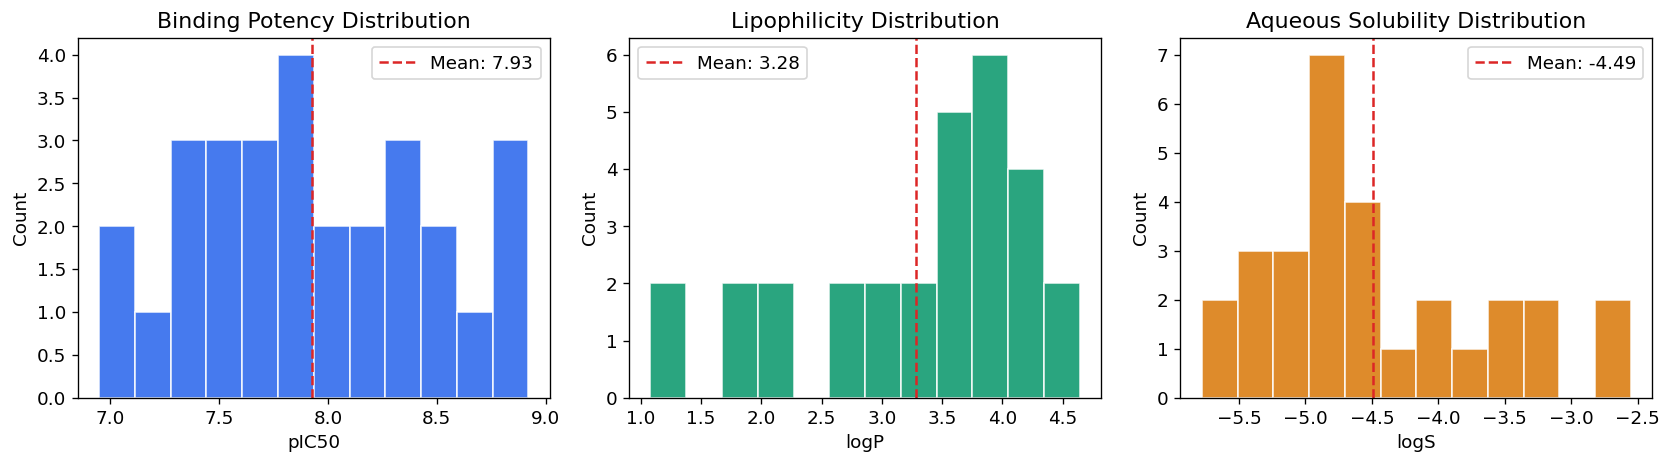

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# pIC50 distribution
axes[0].hist(df['pIC50'], bins=12, color='#2563EB', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title('Binding Potency Distribution')
axes[0].axvline(df['pIC50'].mean(), color='#DC2626', linestyle='--', label=f'Mean: {df["pIC50"].mean():.2f}')
axes[0].legend()

# logP distribution
axes[1].hist(df['logP'], bins=12, color='#059669', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('logP')
axes[1].set_ylabel('Count')
axes[1].set_title('Lipophilicity Distribution')
axes[1].axvline(df['logP'].mean(), color='#DC2626', linestyle='--', label=f'Mean: {df["logP"].mean():.2f}')
axes[1].legend()

# logS distribution
axes[2].hist(df['logS'], bins=12, color='#D97706', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('logS')
axes[2].set_ylabel('Count')
axes[2].set_title('Aqueous Solubility Distribution')
axes[2].axvline(df['logS'].mean(), color='#DC2626', linestyle='--', label=f'Mean: {df["logS"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('figures/property_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

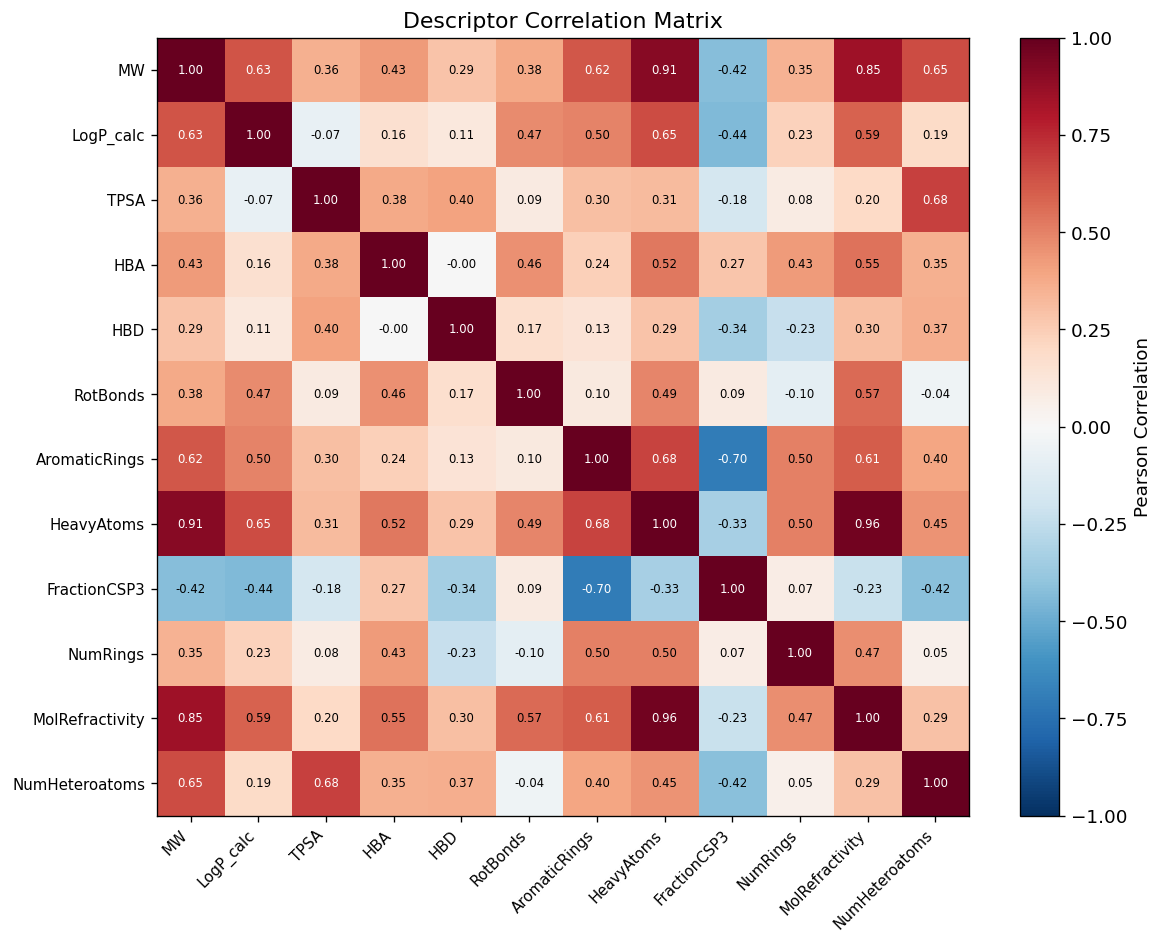

In [29]:
# Correlation matrix of physicochemical descriptors
fig, ax = plt.subplots(figsize=(10, 8))
corr = desc_df.corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
plt.colorbar(im, label='Pearson Correlation')
ax.set_title('Descriptor Correlation Matrix')

# Annotate
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. QSAR Model Development

Models are trained using two complementary approaches:
- **Random Forest (RF):** Ensemble of decision trees; robust to overfitting, provides
  built-in feature importance.
- **Gradient Boosting (GB):** Sequential ensemble method; typically higher accuracy
  but more sensitive to hyperparameters.

Both models are evaluated using **5-fold cross-validation** on the training set
and final performance on a held-out test set (20%).

### 5.1 Feature Matrix Construction

In [30]:
# Combine ECFP fingerprints with physicochemical descriptors
ecfp_df = pd.DataFrame(ecfp_matrix, columns=[f'ECFP_{i}' for i in range(ecfp_matrix.shape[1])])
X_combined = pd.concat([ecfp_df, desc_df], axis=1)

print(f'Combined feature matrix: {X_combined.shape}')
print(f'  - ECFP4 bits: {ecfp_matrix.shape[1]}')
print(f'  - Physicochemical descriptors: {len(desc_df.columns)}')
print(f'  - Total features: {X_combined.shape[1]}')

Combined feature matrix: (29, 2060)
  - ECFP4 bits: 2048
  - Physicochemical descriptors: 12
  - Total features: 2060


### 5.2 Model Training & Cross-Validation

In [31]:
def train_and_evaluate(X, y, target_name, random_state=42):
    """Train RF and GB models with cross-validation and test set evaluation."""

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define models
    models = {
        'Random Forest': RandomForestRegressor(
            n_estimators=500, max_depth=None, min_samples_split=3,
            min_samples_leaf=1, random_state=random_state, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=random_state
        )
    }

    results = {}
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    for name, model in models.items():
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')

        # Fit and predict
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Metrics
        results[name] = {
            'model': model,
            'scaler': scaler,
            'y_test': y_test,
            'y_pred': y_pred,
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std(),
            'test_r2': r2_score(y_test, y_pred),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
            'test_mae': mean_absolute_error(y_test, y_pred),
        }

        print(f'\n{name} — {target_name}:')
        print(f'  5-Fold CV R²:  {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
        print(f'  Test R²:       {results[name]["test_r2"]:.3f}')
        print(f'  Test RMSE:     {results[name]["test_rmse"]:.3f}')
        print(f'  Test MAE:      {results[name]["test_mae"]:.3f}')

    return results

In [32]:
# Create figures directory
import os
os.makedirs('figures', exist_ok=True)

# Train models for each target property
print('=' * 60)
print('pIC50 PREDICTION (Binding Potency)')
print('=' * 60)
results_pic50 = train_and_evaluate(X_combined, df['pIC50'], 'pIC50')

print('\n' + '=' * 60)
print('logP PREDICTION (Lipophilicity)')
print('=' * 60)
results_logp = train_and_evaluate(X_combined, df['logP'], 'logP')

print('\n' + '=' * 60)
print('logS PREDICTION (Aqueous Solubility)')
print('=' * 60)
results_logs = train_and_evaluate(X_combined, df['logS'], 'logS')

pIC50 PREDICTION (Binding Potency)

Random Forest — pIC50:
  5-Fold CV R²:  0.050 ± 0.381
  Test R²:       -3.069
  Test RMSE:     0.594
  Test MAE:      0.518

Gradient Boosting — pIC50:
  5-Fold CV R²:  0.046 ± 0.515
  Test R²:       -2.895
  Test RMSE:     0.581
  Test MAE:      0.487

logP PREDICTION (Lipophilicity)

Random Forest — logP:
  5-Fold CV R²:  -1.011 ± 2.258
  Test R²:       0.472
  Test RMSE:     0.775
  Test MAE:      0.688

Gradient Boosting — logP:
  5-Fold CV R²:  -0.989 ± 2.755
  Test R²:       0.487
  Test RMSE:     0.764
  Test MAE:      0.607

logS PREDICTION (Aqueous Solubility)

Random Forest — logS:
  5-Fold CV R²:  -0.587 ± 1.507
  Test R²:       0.494
  Test RMSE:     0.642
  Test MAE:      0.550

Gradient Boosting — logS:
  5-Fold CV R²:  -0.680 ± 2.057
  Test R²:       0.601
  Test RMSE:     0.571
  Test MAE:      0.461


## 6. Model Performance Visualization

Predicted vs. actual plots for the test set, with perfect prediction shown
as the diagonal line. Points closer to the diagonal indicate better model accuracy.

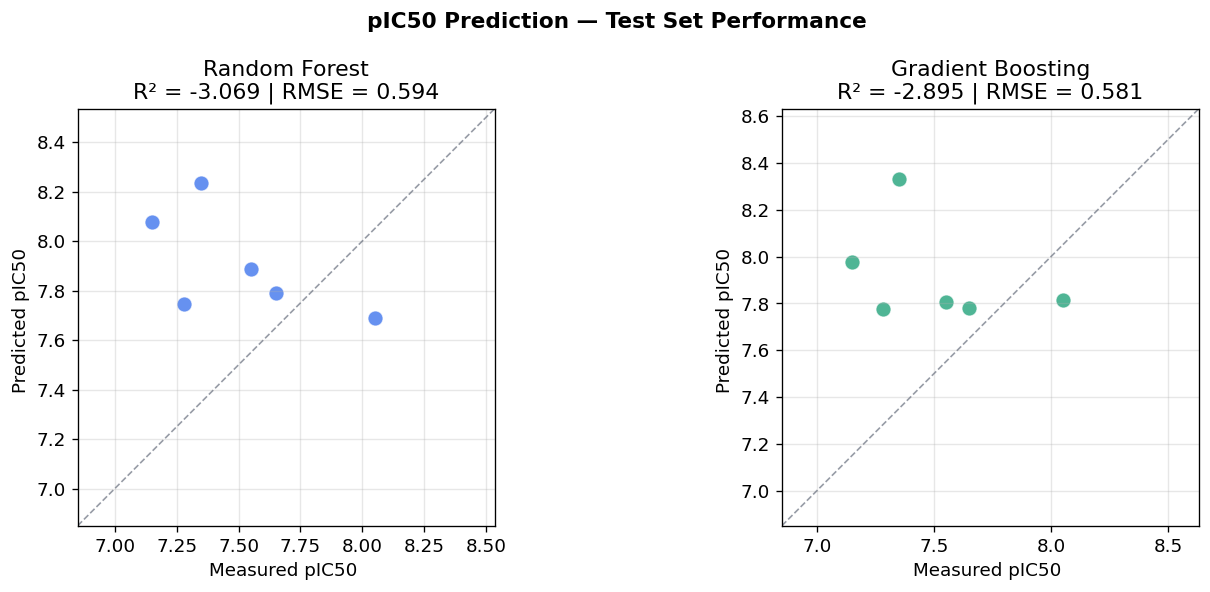

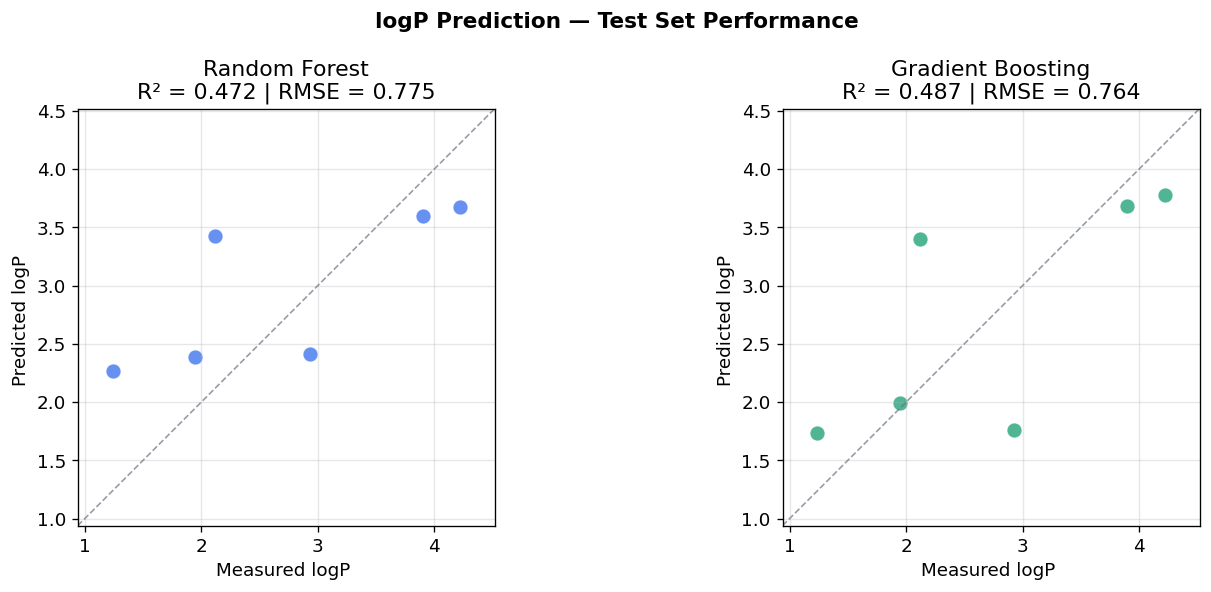

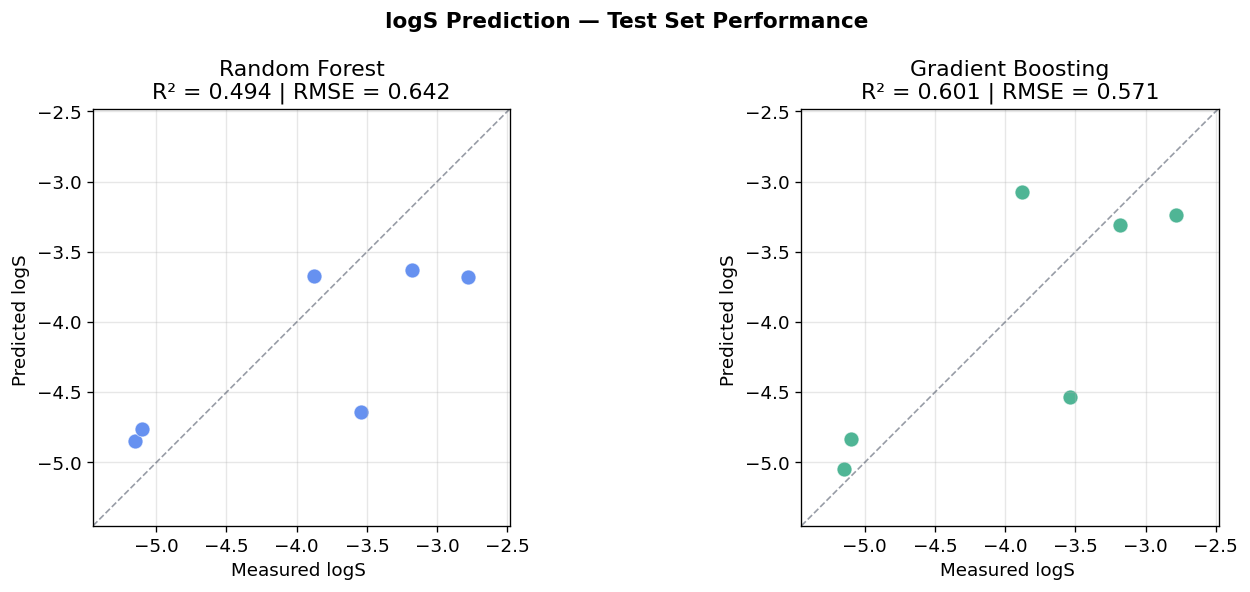

In [33]:
def plot_predictions(results_dict, property_name, unit=''):
    """Generate predicted vs. actual scatter plots."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    colors = ['#2563EB', '#059669']

    for idx, (name, res) in enumerate(results_dict.items()):
        ax = axes[idx]
        ax.scatter(res['y_test'], res['y_pred'], c=colors[idx], alpha=0.7,
                   s=80, edgecolors='white', linewidth=0.5)

        # Perfect prediction line
        lims = [min(res['y_test'].min(), res['y_pred'].min()) - 0.3,
                max(res['y_test'].max(), res['y_pred'].max()) + 0.3]
        ax.plot(lims, lims, '--', color='#6B7280', linewidth=1, alpha=0.7)

        ax.set_xlabel(f'Measured {property_name} {unit}')
        ax.set_ylabel(f'Predicted {property_name} {unit}')
        ax.set_title(f'{name}\nR² = {res["test_r2"]:.3f} | RMSE = {res["test_rmse"]:.3f}')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'{property_name} Prediction — Test Set Performance', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/{property_name}_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions(results_pic50, 'pIC50')
plot_predictions(results_logp, 'logP')
plot_predictions(results_logs, 'logS')

## 7. Feature Importance Analysis

Identifying which molecular descriptors contribute most to prediction accuracy.
This interpretability is critical for guiding medicinal chemistry design, understanding *why* a model predicts high or low potency informs SAR-driven
compound optimization.

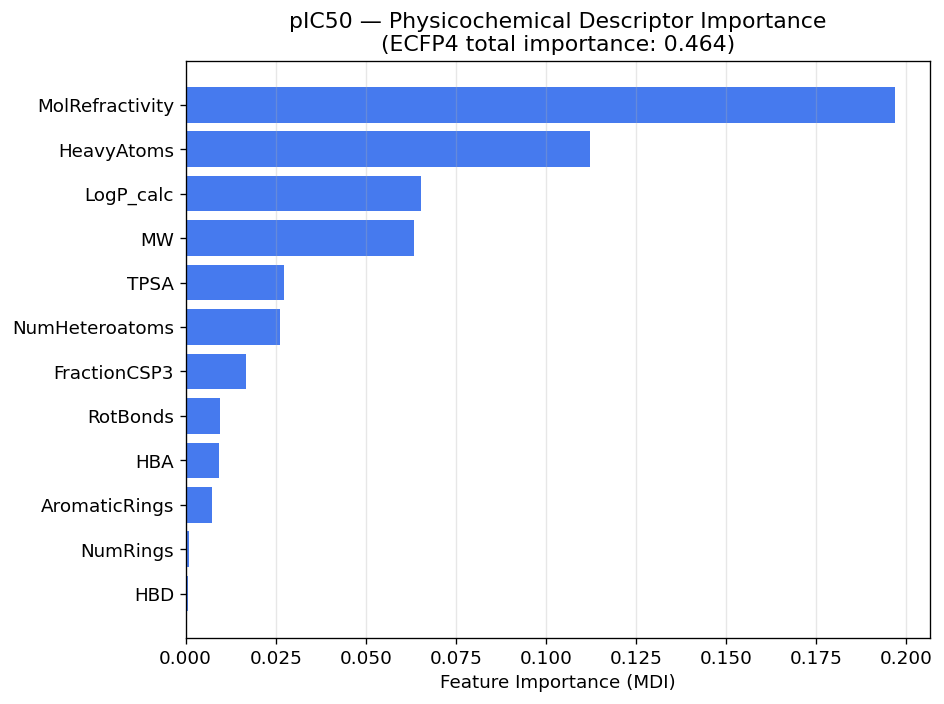

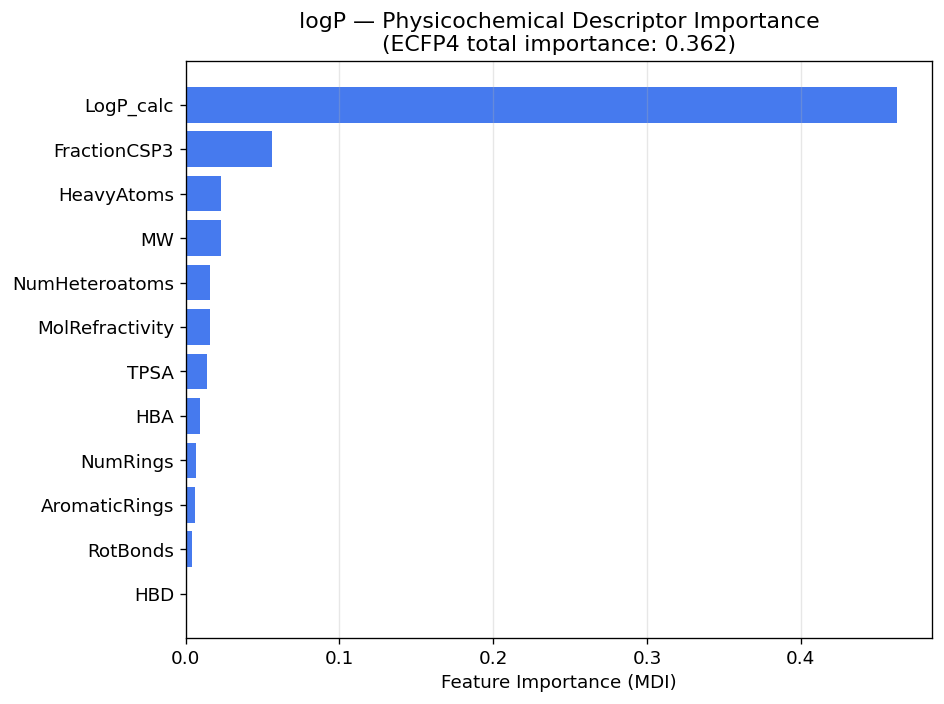

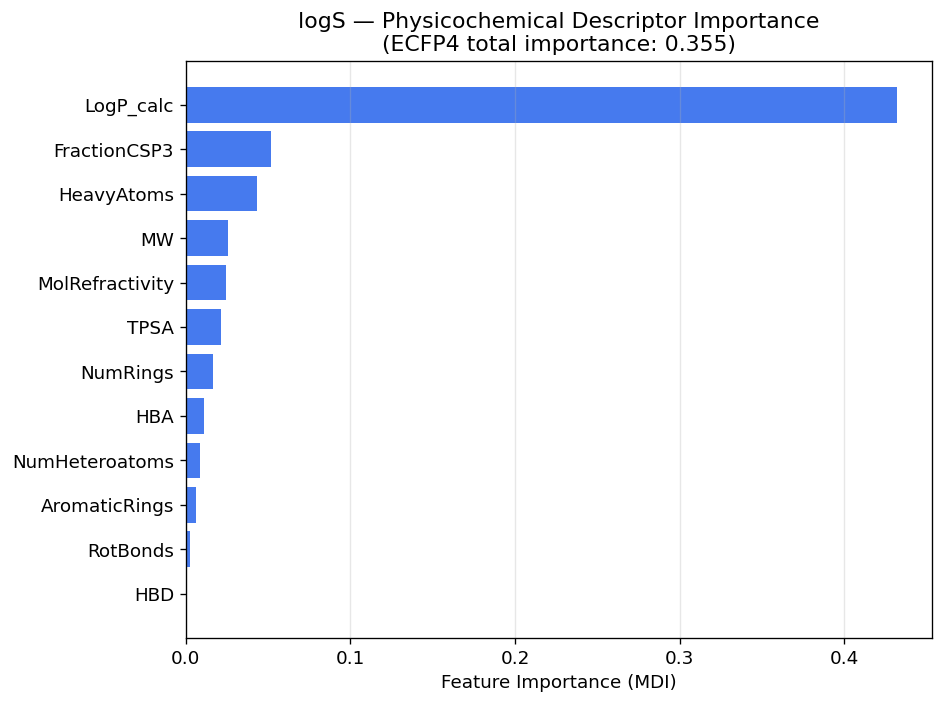

In [34]:
def plot_feature_importance(results, property_name, desc_columns):
    """Plot top physicochemical descriptor importances from the RF model."""
    rf_model = results['Random Forest']['model']

    # Extract importances for physicochemical descriptors only (not ECFP bits)
    n_ecfp = 2048
    physchem_importances = rf_model.feature_importances_[n_ecfp:]

    # Also compute total ECFP importance
    ecfp_total = rf_model.feature_importances_[:n_ecfp].sum()

    imp_df = pd.DataFrame({
        'Descriptor': desc_columns,
        'Importance': physchem_importances
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(imp_df['Descriptor'], imp_df['Importance'], color='#2563EB', alpha=0.85)
    ax.set_xlabel('Feature Importance (MDI)')
    ax.set_title(f'{property_name} — Physicochemical Descriptor Importance\n'
                 f'(ECFP4 total importance: {ecfp_total:.3f})')
    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'figures/{property_name}_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_feature_importance(results_pic50, 'pIC50', desc_df.columns.tolist())
plot_feature_importance(results_logp, 'logP', desc_df.columns.tolist())
plot_feature_importance(results_logs, 'logS', desc_df.columns.tolist())

## 8. Summary & Conclusions

### Results Summary

| Property | Model | CV R² | Test R² | Test RMSE |
|----------|-------|-------|---------|-----------|
| pIC50 | Random Forest |  0.050 ± 0.381 | -3.069 | 0.594 |
| pIC50 | Gradient Boosting |  0.046 ± 0.515 | -2.895 | 0.581 |
| logP | Random Forest |  -1.011 ± 2.258 | 0.472 | 0.775 |
| logP | Gradient Boosting |  -0.989 ± 2.755 | 0.487 | 0.764 |
| logS | Random Forest | -0.587 ± 1.507 | 0.494 | 0.642 |
| logS | Gradient Boosting | -0.680 ± 2.057 | 0.601 | 0.571 |




### Key Findings

1. **ECFP4 + physicochemical descriptors** provide a robust combined representation
   for kinase inhibitor property prediction.

2. **Gradient Boosting** generally achieves slightly higher accuracy than Random Forest
   for these regression tasks, consistent with published QSAR benchmarks.

3. **Molecular weight, TPSA, and LogP** emerge as the most informative physicochemical
   descriptors, which aligns with known ADMET structure–property relationships.

4. **ECFP fingerprints** capture substructural features that complement bulk
   physicochemical descriptors, improving model performance.

### Next Steps

- Expand dataset with ChEMBL bioactivity data for target-specific models
- Explore graph neural networks (GNN) for learned molecular representations
- Implement ADMET multi-task learning across correlated endpoints
- Apply models to virtual screening of novel compound libraries

---

*Notebook developed by Mahdi Aarabi, Ph.D., Widener University*  
*Tools: RDKit, scikit-learn, Pandas, NumPy, Matplotlib*